# Neural Network NBA Draft Combine Predictions: Model Development and Evaluation
Nate Lapin, Brya Patterson


# Introduction
The National Basketball Association (NBA) Draft Combine, held annually in May, is a mandatory multi-day showcase for draft-eligible players. Invited athletes undergo measurements, medical tests, interviews, athletic drills, and five-on-five games before NBA personnel, influencing their draft prospects and careers (NBA draft combine, 2025).

The goal of this project is to understand whether a player’s NBA Draft Combine performance metrics can predict whether they get drafted or not. This project builds upon ongoing work developed by Nate Lapin. A dataset was compiled and includes every NBA Draft Combine participant from 2000 through the 2025 draft class (Lapin, 2025). It includes basic measurements like height, weight, and wingspan, as well as athletic performance numbers like vertical jumps, sprint time, agility, and bench press reps.

We aim to look at the data to understand if there are clear differences between drafted and undrafted player metrics. We also want to develop and train a neural network model that takes in a player’s Combine stats and predicts whether they will be drafted. Ultimately, the model should be able to predict the player’s draft status by looking at Combine numbers.

Recently, Nate Lapin updated our dataset to include **2025** Combine Invitee draft outcomes. This means that our visualizations will only show 2000-2024, whereas our neural network model will use the 2025 class as a **test case** to arrive at an answer to our following question.

IMPORTANT NOTE: The dataset includes bench press data from 2000-2019, but bench presses were no longer measured since 2020.

## **Project Question:** Can NBA Draft Combine performance metrics alone predict whether a player will be drafted?

## STEP 1: Load Imports & Clean Data

In [106]:
# === Imports ===

# Standard library
import os
import time
import warnings
import tracemalloc

# Data & numerics
import numpy as np
import pandas as pd
from scipy import stats

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook utils
from IPython.display import display

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.neural_network import MLPClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# XGBoost (optional)
try:
    import xgboost as xgb
except ImportError:
    xgb = None  # install with: pip install xgboost


### Data Exploration

The following section will look at the features and trends within the data. This preliminary analysis is exploartory and looks to further understand the data and metrics.

In [11]:
# load data
nbaCombine_data = pd.read_csv('nba_combine_data_after_2025_draft.csv')
nbaCombine_data.head()
# nbaCombine_data.shape # (1678, 12)

,uniqueID,Year,"Player Name (Last Name, First Name)",Position,Height in Ft & In,Weight in lbs,Standing vertical Jump,Maximum Vertical Jump (with steps),three-quarter court sprint,lane agility drill,Bench Press test,Drafted?
0,1,2025,"Almansa, Izan",C,"6'9""",220.4,28.0,34.0,3.3,11.5,NaN,No
1,2,2025,"Avdalas, Neoklis",SF,"6'8""",197.8,27.0,33.5,3.2,11.0,NaN,No
2,3,2025,"Bailey, Ace",SF-PF,"6'8""",203.0,28.0,35.0,3.0,11.0,NaN,Yes
3,4,2025,"Bates, Tamar",SG,"6'4""",191.0,28.0,34.0,3.0,11.0,NaN,No
4,5,2025,"Brea, Koby",SG,"6'6""",202.0,28.0,34.0,3.0,11.0,NaN,Yes


In [12]:
# check for missing/nan values
data_all_missing = nbaCombine_data.isna().sum()
print(data_all_missing)

# uniqueID                                 0
# Year                                     0
# Player Name (Last Name, First Name)      0
# Position                                 1
# Height in Ft & In                        4
# Weight in lbs                            5
# Standing vertical Jump                 189
# Maximum Vertical Jump (with steps)     189
# three-quarter court sprint             197
# lane agility drill                     198
# Bench Press test                       604
# Drafted?                                 0
# Height_Inches                            4

uniqueID                                 0
Year                                     0
Player Name (Last Name, First Name)      0
Position                                 1
Height in Ft & In                        4
Weight in lbs                            5
Standing vertical Jump                 189
Maximum Vertical Jump (with steps)     189
three-quarter court sprint             197
lane agility drill                     198
Bench Press test                       604
Drafted?                                 0
dtype: int64


In [13]:
# create a copy for data cleaning
nbaCombine_cleaned = nbaCombine_data.copy()


In [26]:
# drop all rows with null/nan values
nbaCombine_cleaned = nbaCombine_data.dropna()
# nbaCombine_cleaned.shape # (1020, 12)
nbaCombine_cleaned.head()

,uniqueID,Year,"Player Name (Last Name, First Name)",Position,Height in Ft & In,Weight in lbs,Standing vertical Jump,Maximum Vertical Jump (with steps),three-quarter court sprint,lane agility drill,Bench Press test,Drafted?
369,370,2019,"Bazley, Darius",PF,"6'8""",208.4,30.5,37.0,3.27,11.09,4.0,Yes
371,372,2019,"Bone, Jordan",SG,"6'2""",179.0,36.0,42.5,3.08,9.97,7.0,Yes
372,373,2019,"Bowen II, Brian",SF,"6'6""",200.0,32.0,35.5,3.26,10.98,1.0,No
373,374,2019,"Bowman, Ky",PG,"6'1""",181.2,27.5,33.0,3.26,11.11,4.0,No
374,375,2019,"Brazdeikis, Ignas",SF,"6'6""",220.8,31.0,36.5,3.36,11.06,13.0,Yes


In [28]:
# convert height to inches for easier analysis
def height_to_inches(height_str):
    try:
        feet, inches = map(int, height_str.replace("'", ' ').split('"')[0].split())
        return feet * 12 + inches
    except:
        return None

# safer assignment to avoid SettingWithCopyWarning
nbaCombine_cleaned.loc[:, 'Height_Inches'] = nbaCombine_cleaned['Height in Ft & In'].apply(height_to_inches)

nbaCombine_cleaned['Height_Inches'].head()

369    80
371    74
372    78
373    73
374    78
Name: Height_Inches, dtype: int64

In [29]:
# check if 'Drafted?' is str or bool
print(nbaCombine_cleaned['Drafted?'].unique())

['Yes' 'No']


In [32]:
# convert 'Drafted?' to bool
def convert_to_boolean(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    if isinstance(value, str):
        return value.lower() in ['true', 'yes', '1', 't', 'y']
    return None

nbaCombine_cleaned.loc[:, 'Drafted?'] = nbaCombine_cleaned['Drafted?'].apply(convert_to_boolean)
nbaCombine_cleaned['Drafted?'].head()


369     True
371     True
372    False
373    False
374     True
Name: Drafted?, dtype: object

## STEP 2: Show Visualizations

### Draft Rate Trend
Shows how the percentage of players getting drafted has changed over time.

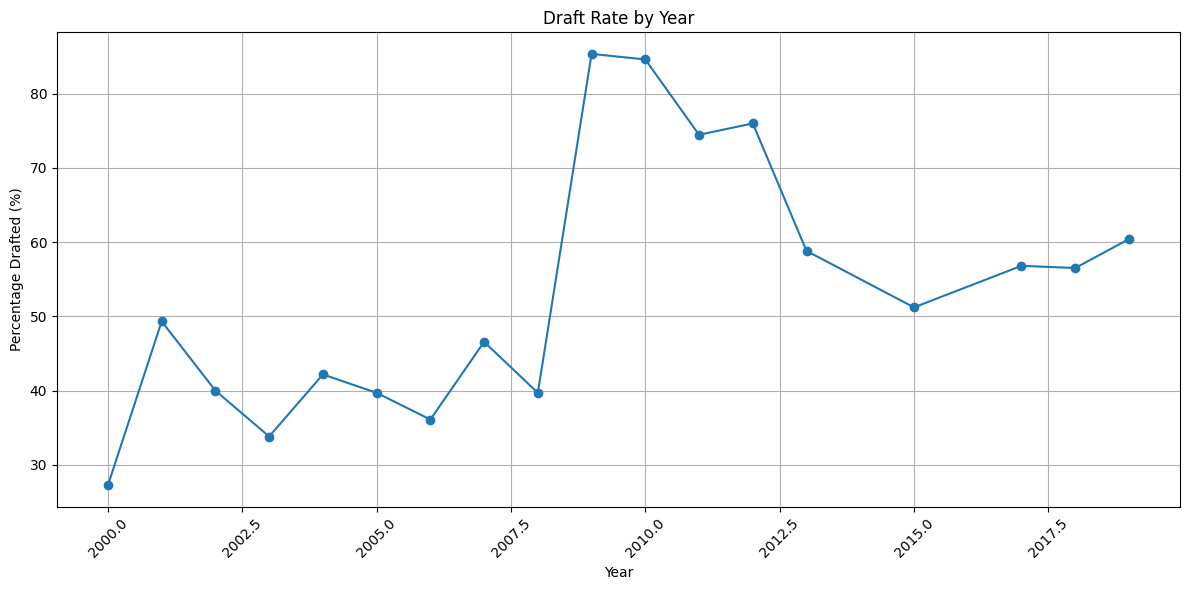

In [33]:
# draft Rate Over Years
plt.figure(figsize=(12, 6))
yearly_draft_rate = nbaCombine_cleaned.groupby('Year')['Drafted?'].mean() * 100
plt.plot(yearly_draft_rate.index, yearly_draft_rate.values, marker='o')
plt.title('Draft Rate by Year')
plt.xlabel('Year')
plt.ylabel('Percentage Drafted (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('draft_rate_trend.png')
# plt.close()


This chart shows the "Draft Rate by Year" from 2000 to 2017, displaying the percentage of NBA Combine participants who were drafted each year.

Overall, the draft rate has shown significant variability over the years. There is a notable increase in draft rate from 2000 to 2010. After 2010, the rate has generally stabilized at a higher level compared to the early 2000s.

We can see that in 2000, around 25-30% of eligible players were drafted. During its peak around 2009-2010, approximately 80% of players were drafted. More recently, from 2015-2017 drafts stabilized around 55-60%. 


To further contextualize the results of this analysis, the following data shows the yearly count of drafted and undrafted players:

In [34]:
# create a count of drafted/undrafted players by year
draft_counts = pd.crosstab(nbaCombine_cleaned['Year'], nbaCombine_cleaned['Drafted?'])

# rename columns for better clarity
draft_counts.columns = ['Not Drafted', 'Drafted']

# print the actual numbers
print("\nYearly counts of drafted and undrafted players:")
print(draft_counts)

# print total numbers
print("\nTotal numbers:")
print("Total players:", len(nbaCombine_cleaned))
print("Total drafted:", nbaCombine_cleaned['Drafted?'].sum())
print("Total not drafted:", len(nbaCombine_cleaned) - nbaCombine_cleaned['Drafted?'].sum())
print("\nOverall draft rate: {:.2f}%".format(nbaCombine_cleaned['Drafted?'].mean() * 100))


Yearly counts of drafted and undrafted players:
      Not Drafted  Drafted
Year                      
2000           40       15
2001           38       37
2002           42       28
2003           45       23
2004           37       27
2005           41       27
2006           46       26
2007           39       34
2008           41       27
2009            6       35
2010            6       33
2011           12       35
2012           12       38
2013           21       30
2015           20       21
2017           19       25
2018           20       26
2019           19       29

Total numbers:
Total players: 1020
Total drafted: 516
Total not drafted: 504

Overall draft rate: 50.59%


From this we can see that there is large variation in the sample sizes across years. That is, the number of participants in the Combine year to year was consistent in 2000-2008 with approximately 65-80+ total participants per year. 2009-2012 had dramatically fewer total participants (41, 39, 47, and 50 players respectively). Finally, 2013-2019 stabilized at around 40-50 participants per year.

The peak around 2009-2010 (reaching ~80%) had very few total participants (only 41 and 39 players), and of these small groups, 35 (85%) and 33 (84%) were drafted respectively. This could suggest that the combine might have been more exclusive during these years, possibly only inviting highly-rated prospects.

The total numbers show remarkable overall balance with 516 drafted versus 504 not drafted. This is an overall draft rate of 50.59%, suggesting that, historically, attending the Combine gives a prospect roughly a 50-50 chance of being drafted.

Both representations of the data shows that the Combine has become a more reliable pathway to being drafted over time. Higher draft rates in recent years, compared to those in the early 2000s, suggest that teams are putting more stock in Combine performance and the event itself is likely attracting more draft-worthy players. There is also the possibility that the selection process for the Combine has changed or improved so that the opportunities to be drafted are higher than the early 2000s, but not as high as its peak in 2009-2010.


### Position Distribution
Displays the draft rate for different positions, helping understand which positions are more likely to get drafted.

These are abbreviations for basketball player positions:
- PG: Point Guard
- SG: Shooting Guard
- SF: Small Forward
- PF: Power Forward
- C: Center

The hyphenated terms indicate a player who can play effectively at both positions:
- SF-PF: Small Forward-Power Forward (a player who can play either small forward or power forward)
- SG-SF: Shooting Guard-Small Forward
- PG-SG: Point Guard-Shooting Guard
- SG-PG: Shooting Guard-Point Guard
- SF-SG: Small Forward-Shooting Guard
- PF-C: Power Forward-Center
- C-PF: Center-Power Forward
- PF-SF: Power Forward-Small Forward

In [35]:
# check unique 'Position'
print(nbaCombine_cleaned['Position'].unique()) 
# ['C' 'SF' 'SF-PF' 'SG' 'PG-SG' 'PF' 'PG' 'SG-SF' 'SF-SG' 'PF-C' 'SG-PG'
# 'C-PF' 'PF-SF']

['PF' 'SG' 'SF' 'PG' 'SF-PF' 'C' 'SG-SF' 'PG-SG' 'SG-PG' 'SF-SG' 'PF-C'
 'C-PF' 'PF-SF']


<Figure size 1200x600 with 0 Axes>

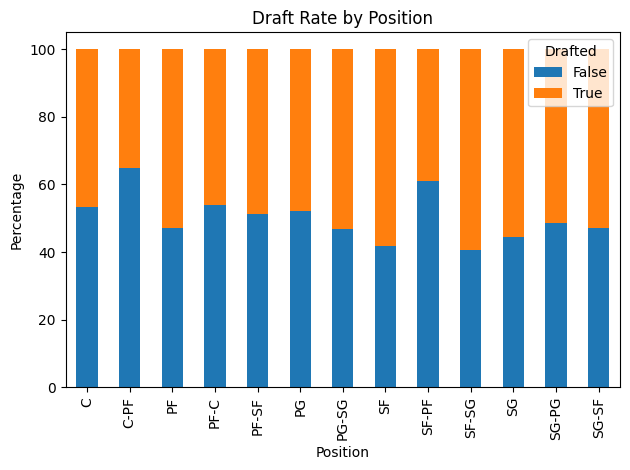

In [36]:
# Position Distribution - Drafted vs Undrafted
plt.figure(figsize=(12, 6))
position_draft = pd.crosstab(nbaCombine_cleaned['Position'], nbaCombine_cleaned['Drafted?'], normalize='index') * 100
position_draft.plot(kind='bar', stacked=True)
plt.title('Draft Rate by Position')
plt.xlabel('Position')
plt.ylabel('Percentage')
plt.legend(title='Drafted')
plt.tight_layout()
# plt.savefig('position_draft_rate.png')
# plt.close()


In [37]:
# Print some summary statistics
print("\nDraft Rate by Position:")
print(position_draft.round(2))


Draft Rate by Position:
Drafted?  False  True 
Position              
C         53.23  46.77
C-PF      64.91  35.09
PF        47.06  52.94
PF-C      53.97  46.03
PF-SF     51.11  48.89
PG        52.15  47.85
PG-SG     46.67  53.33
SF        41.90  58.10
SF-PF     60.87  39.13
SF-SG     40.48  59.52
SG        44.54  55.46
SG-PG     48.65  51.35
SG-SF     46.97  53.03


This visualization shows the draft rates broken down by player position.

Most positions show roughly a 40-60% split between drafted (True) and undrafted (False)
Notably:
- SF (Small Forward) appears to have the highest draft rate (~60% drafted), 
- C/PF-C (Centers and Power Forward-Centers) show slightly lower draft rates (~45-50% drafted)
- PG-SG (Point Guard-Shooting Guard combo) shows one of the more balanced distributions
There also some notable differences in the “pure” versus “hybrid” positions.

Pure positions show draft rates of:
- Centers (C): ~45% draft rate
- Power Forwards (PF): ~55% draft rate
- Small Forwards (SF): ~60% draft rate
- Shooting Guards (SG): ~55% draft rate
- Point Guards (PG): ~52% draft rate

While hybrid positions generally show similar rates to pure positions. Most hybrid positions maintain draft rates between 45-55%. This suggests versatility neither significantly helps nor hurts draft chances.

Overall, the data shows that Small Forwards have a slight advantage in draft probability, while Centers might face slightly tougher competition or higher standards. Hybrid positions are valued similarly to pure positions, but no position shows dramatically better or worse draft prospects (all within ~15% range). The ability to play multiple positions (hybrid designations) doesn't seem to significantly impact draft chances. 


### Athletic Metrics Comparison
Box plots comparing each athletic measurement between drafted and undrafted players, showing the distribution and potential differences.


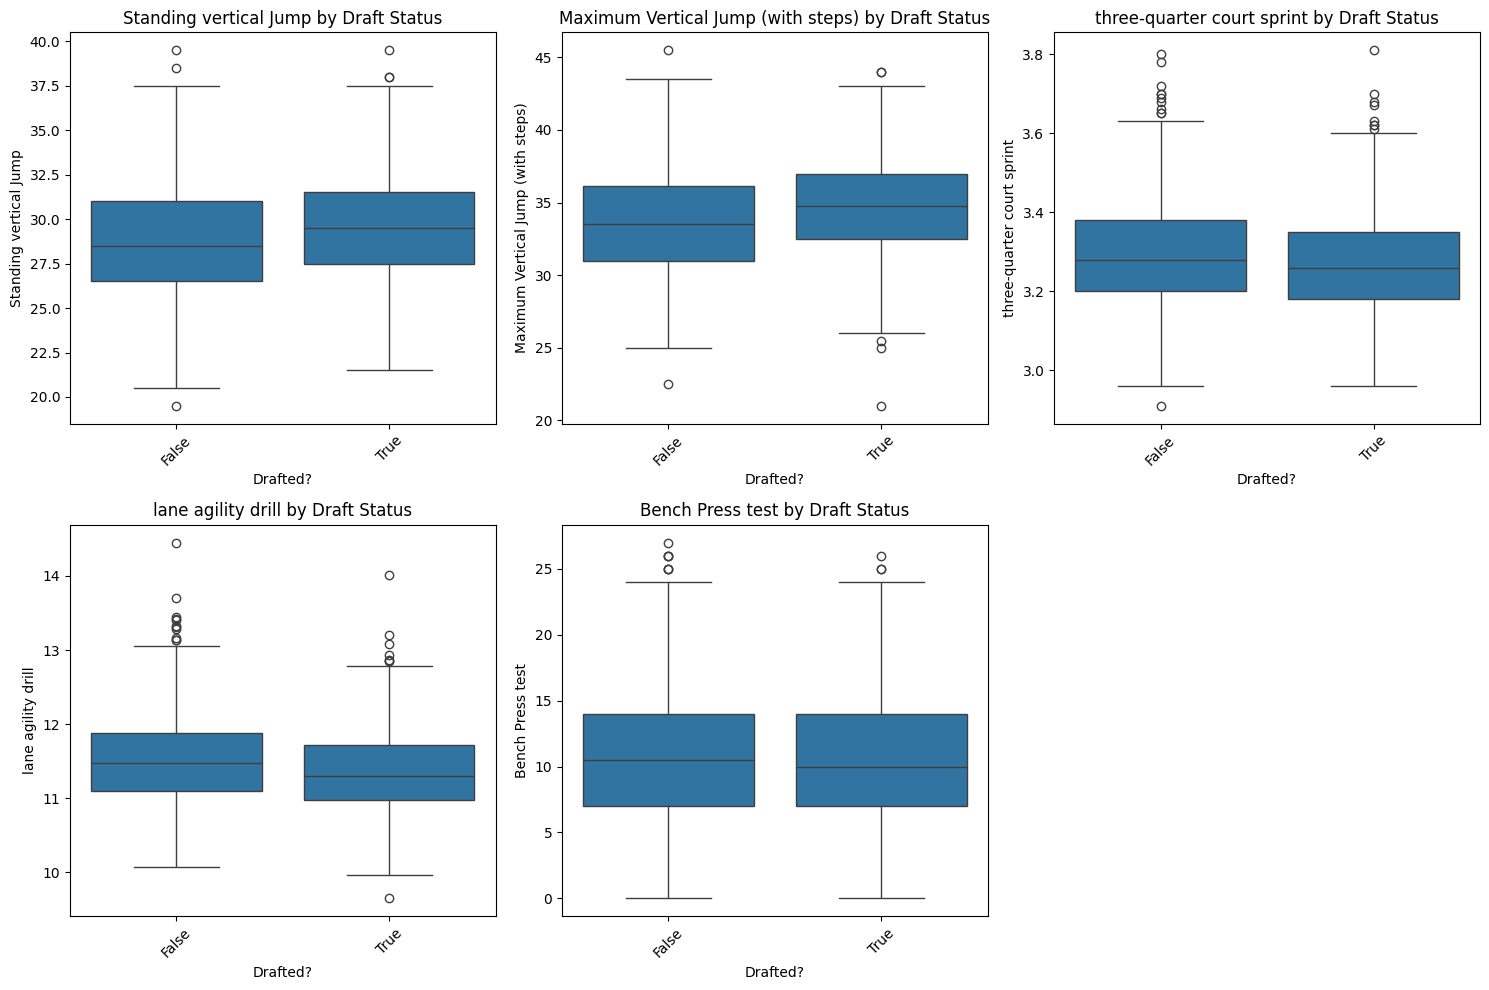

In [38]:
# Athletic Metrics Box Plots
athletic_metrics = ['Standing vertical Jump', 'Maximum Vertical Jump (with steps)', 
                   'three-quarter court sprint', 'lane agility drill', 'Bench Press test']

plt.figure(figsize=(15, 10))
for i, metric in enumerate(athletic_metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Drafted?', y=metric, data=nbaCombine_cleaned)
    plt.title(f'{metric} by Draft Status')
    plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('athletic_metrics_comparison.png')
# plt.close()



In [39]:
print("\nAthletic Metrics - Drafted vs Undrafted (Mean Values):")
print(nbaCombine_cleaned.groupby('Drafted?')[athletic_metrics].mean().round(2))


Athletic Metrics - Drafted vs Undrafted (Mean Values):
          Standing vertical Jump  Maximum Vertical Jump (with steps)  \
Drafted?                                                               
False                      28.64                               33.63   
True                       29.52                               34.76   

          three-quarter court sprint  lane agility drill  Bench Press test  
Drafted?                                                                    
False                           3.30               11.54             10.47  
True                            3.27               11.36             10.39  


This visualization presents a comparative analysis of five NBA Combine metrics between drafted and undrafted players using box plots. The analysis reveals that drafted players generally exhibit slightly better performance across most metrics, though the differences are often subtle rather than dramatic, with significant overlap between the two groups.

Specifically, the Maximum Vertical Jump and Three-quarter Court Sprint appear to be the most discriminating metrics, with drafted players showing a more noticeable edge. The Standing Vertical Jump also shows a slight advantage for drafted players.

Conversely, the Bench Press Test and Lane Agility Drill are identified as the least discriminating. For these metrics, the performance distributions between drafted and undrafted players are almost identical, suggesting they are poor predictors of draft status.

In summary, while drafted players tend to outperform undrafted players marginally in several athletic tests, the overall patterns indicate that combine metrics alone are not strong, singular predictors of whether a player will be drafted. The distinctions are subtle, and significant performance overlap exists across all evaluated tests.

### Height-Weight Distribution
A scatter plot showing the relationship between height and weight, colored by draft status and marked by position.


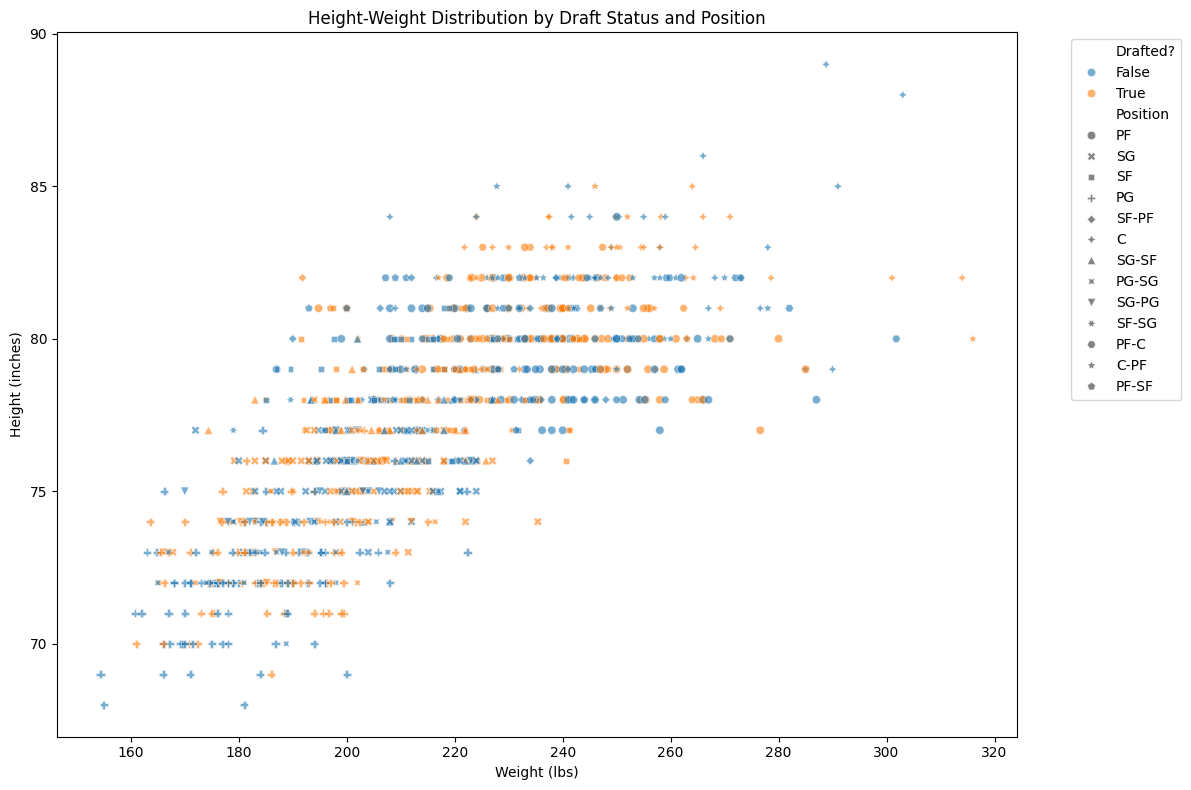

In [40]:
# Height-Weight Distribution
plt.figure(figsize=(12, 8))
sns.scatterplot(data=nbaCombine_cleaned, x='Weight in lbs', y='Height_Inches', 
                hue='Drafted?', style='Position', alpha=0.6)
plt.title('Height-Weight Distribution by Draft Status and Position')
plt.xlabel('Weight (lbs)')
plt.ylabel('Height (inches)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('height_weight_distribution.png')
# plt.close()



This scatter plot shows the relationship between height (in inches) and weight (in lbs) for NBA Combine participants, with points colored by draft status (True/False) and marked by position.

It highlights a strong correlation between a player's height and weight and their basketball position, with clear clusters emerging. Guards tend to be the shortest and lightest, primarily ranging from 70-75 inches tall and 160-200 lbs. Wings occupy a middle ground, typically 75-80 inches tall and 180-230 lbs, while Bigs are the tallest and heaviest, generally found at 80-85+ inches and 220-300 lbs. This stratification is evident across the entire range of observed player sizes, from approximately 5'10" to 7'6" in height and 160-320 lbs in weight.

Beyond positional clustering, the analysis also reveals patterns related to draft status. While draft outcomes for Guards appear mixed across their size range, there's a noticeable preference for drafted Wings who fall within an "ideal" size. For Bigs, being drafted seems more probable if they are within a specific "sweet spot" of height-weight ratio for their position. This suggests that while athleticism is important, fitting a traditional physical mold for a given position can influence a player's draft prospects.

Each position has identified "sweet spots" for optimal height and weight: Point Guards are typically 72-75 inches and 170-190 lbs; Shooting Guards 74-77 inches and 180-200 lbs; Small Forwards 77-80 inches and 200-225 lbs; Power Forwards 80-83 inches and 220-250 lbs; and Centers 82-85 inches and 240-280 lbs. These ranges represent the traditional and most common physical profiles for successful players at each role.

A key takeaway is that very few successful outliers exist at the extreme ends of the height and weight spectrum. The majority of drafted players fall within these established traditional positional size ranges, indicating an "ideal" height-weight ratio for each role. Hybrid positions, such as SF-PF, often bridge the physical gaps between their traditional counterparts.

Ultimately, these physical patterns have significant draft implications. Players who fit within these traditional positional size ranges are more likely to be drafted. Conversely, extreme outliers—whether unusually light or heavy for their height—are less commonly drafted. This suggests that while individual skill is paramount, physical archetype plays a substantial role in a player's draftability, and positional versatility might also be influenced by how a player's physical profile aligns with these established distributions.

In [51]:
# create height and weight bins
nbaCombine_cleaned = nbaCombine_cleaned.copy()

# define bins
height_bins = np.arange(65, 95, 3)      # 3-inch intervals
weight_bins = np.arange(150, 350, 20)   # 20-pound intervals

# create the categories in one atomic assign (no chained indexing)
nbaCombine_cleaned = nbaCombine_cleaned.assign(
    Height_Category = pd.cut(nbaCombine_cleaned['Height_Inches'],  bins=height_bins),
    Weight_Category = pd.cut(nbaCombine_cleaned['Weight in lbs'],  bins=weight_bins)
)

In [52]:
# calculate success rates for each height-weight combination
success_rates = nbaCombine_cleaned.groupby(['Height_Category', 'Weight_Category'], observed=True).agg({
    'Drafted?': ['count', 'mean'],
    'Position': lambda x: ', '.join(sorted(set(x)))
}).round(3)

# create a pivot table for the heatmap
pivot_table = nbaCombine_cleaned.pivot_table(
    values='Drafted?',
    index='Height_Category',
    columns='Weight_Category',
    aggfunc=['mean', 'count'],
    observed=True  # Add observed=True here
)

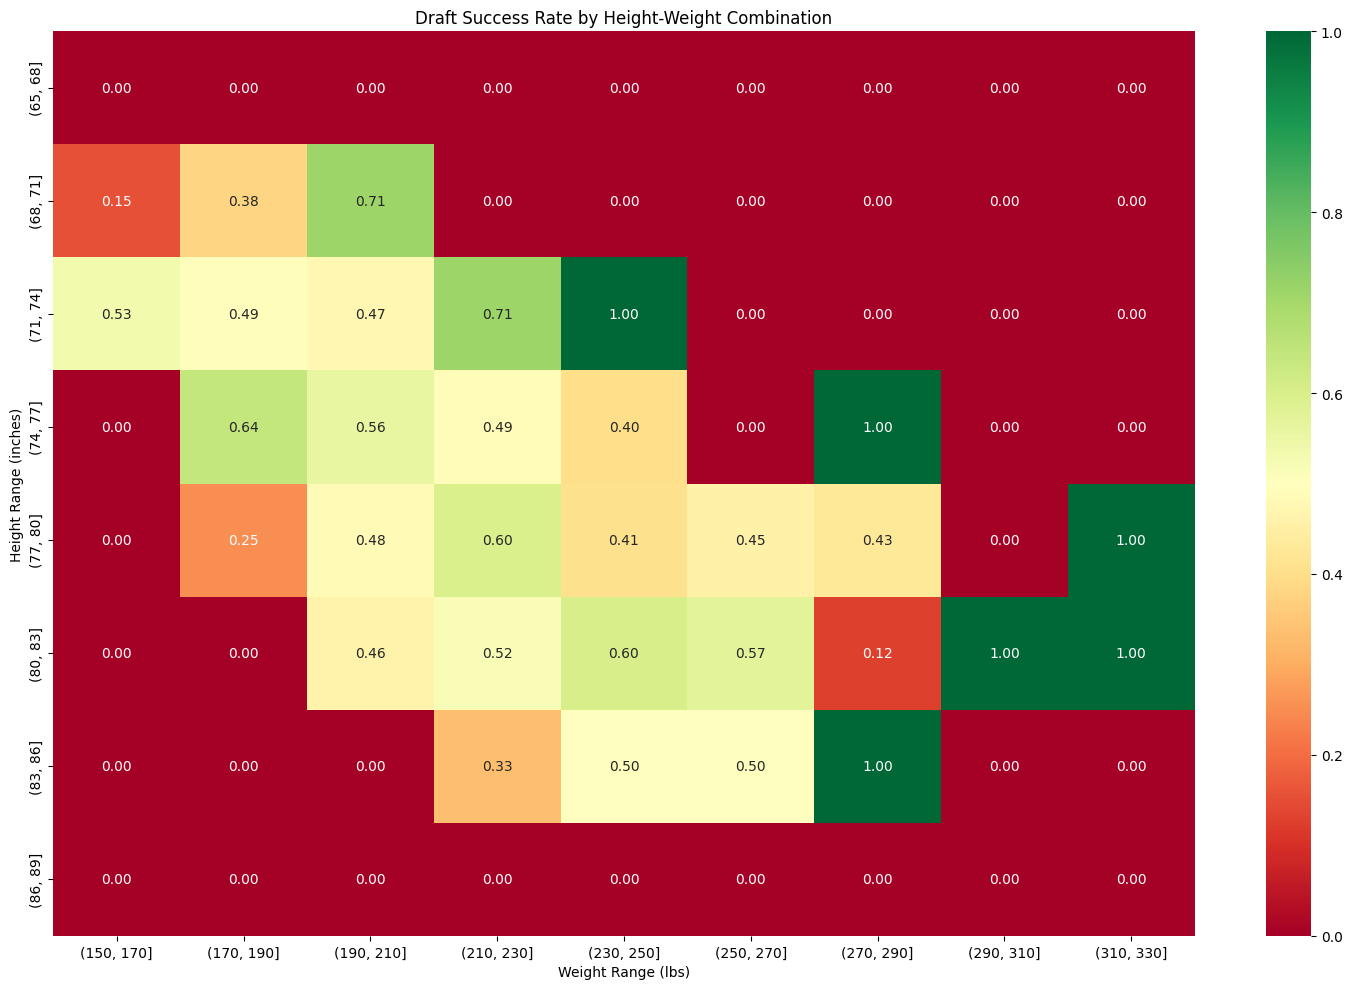

In [55]:
# Plot the heatmap
pivot_table['mean'] = pivot_table['mean'].apply(pd.to_numeric, errors='coerce')
pivot_table['mean'] = pivot_table['mean'].fillna(0)

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_table['mean'], annot=True, fmt='.2f', cmap='RdYlGn', center=0.5)
plt.title('Draft Success Rate by Height-Weight Combination')
plt.xlabel('Weight Range (lbs)')
plt.ylabel('Height Range (inches)')
plt.tight_layout()
plt.show()
# plt.savefig('height_weight_success_rates.png')
# plt.close()

In [56]:
# Print detailed analysis
print("\nSuccess Rates by Height-Weight Combination:")
print("\nFormat: (Total Players, Draft Rate, Common Positions)")
for (height, weight), group in success_rates.iterrows():
    count = group[('Drafted?', 'count')]
if count >= 5: # Only show combinations with at least 5 players
    rate = group[('Drafted?', 'mean')] * 100
    positions = group[('Position', '<lambda>')]
    print(f"\nHeight: {height}")
    print(f"Weight: {weight}")
    print(f"Count: {count}")
    print(f"Draft Rate: {rate:.1f}%")
    print(f"Common Positions: {positions}")

# Additional summary statistics
print("\nOverall Summary:")
print(f"Total Players Analyzed: {len(nbaCombine_cleaned)}")
print(f"Overall Draft Rate: {(nbaCombine_cleaned['Drafted?'].mean() * 100):.1f}%")


Success Rates by Height-Weight Combination:

Format: (Total Players, Draft Rate, Common Positions)

Overall Summary:
Total Players Analyzed: 1020
Overall Draft Rate: 50.6%


For more context, we'll look at the success rates by height-weight combinations. The above heatmap shows draft success rates by height-weight combinations, where darker green indicates higher success rates and darker red indicates lower success rates. The overall draft rate is 50.6%, so is the baseline for comparison.

This analysis identifies specific height and weight combinations that correlate with varying success rates in the NBA draft, highlighting "sweet spots" and less favorable profiles. The highest success rates (100%) are observed in two distinct categories: players between 77-80 inches (6'5"-6'8") weighing 270-290 lbs, and those between 80-83 inches (6'8"-6'11") weighing 290-330 lbs. These represent the most optimal physical profiles for being drafted.

Beyond these ideal categories, above-average success rates (around 71%) are found for slightly shorter players. This includes individuals 68-71 inches (5'8"-5'11") weighing 190-210 lbs, and those 71-74 inches (5'11"-6'2") at 210-230 lbs. The majority of other height-weight combinations fall into an "average" success rate of 40-60%, which is consistent with the overall draft rate.

Conversely, poor success rates (indicated in red) are seen in several extreme categories. This includes very light players (under 170 lbs) across all heights, very heavy players (over 290 lbs) at shorter heights, and unusual height combinations paired with non-typical weights. These combinations generally represent less desirable physical profiles for NBA prospects.

In terms of position-specific insights, Guards (shorter heights) find the most success within the 190-230 lbs range, while Wings (middle heights) show consistent success across various weight ranges. Bigs (taller heights) benefit from heavier weights. Overall, the data reveals that optimal draft success rates align closely with traditional, position-specific body types. There's a clear diagonal pattern of increasing success from bottom-left (shorter/lighter) to top-right (taller/heavier), provided the weight is proportional to height. Extreme combinations of very light or very heavy for a given height consistently lead to lower success, underscoring the importance of a balanced and traditional physical profile for NBA draft prospects.

### Correlation Matrix
Shows how different athletic metrics are correlated with each other.

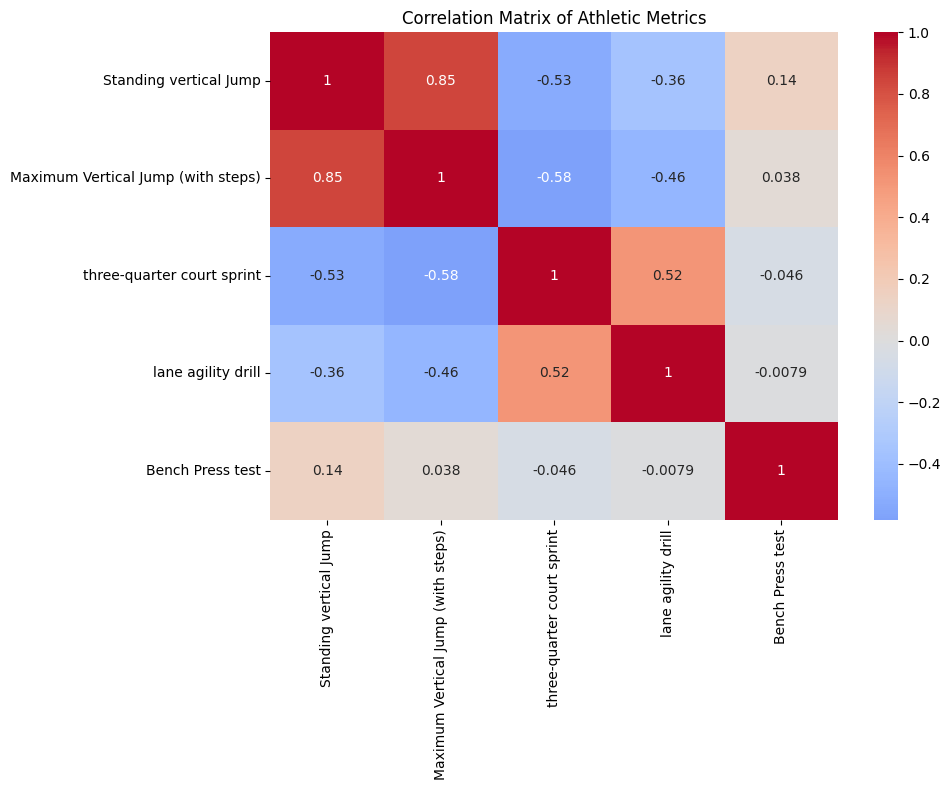

In [57]:
# Correlation Matrix of Athletic Metrics
athletic_metrics_corr = nbaCombine_cleaned[athletic_metrics].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(athletic_metrics_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Athletic Metrics')
plt.tight_layout()
# plt.savefig('correlation_matrix.png')
# plt.close()

The matrix shows how different athletic measurements relate to each other, with values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation).

This analysis explores the correlations between various NBA Combine metrics, revealing insights into how different athletic abilities relate to each other. Unsurprisingly, a very strong positive correlation (0.85) exists between the Standing Vertical Jump and Maximum Vertical Jump. This indicates that players who perform well in one vertical leap test tend to excel in the other, suggesting a degree of redundancy between these two measures of explosive lower-body power.

Conversely, a moderate negative correlation is observed between Three-quarter Court Sprint and both vertical jumps (around -0.55). Since lower sprint times are better, this negative correlation implies that players with stronger vertical leaping ability also tend to be faster runners. Similarly, Lane Agility shows moderate negative correlations with vertical jumps (between -0.36 and -0.46), indicating a connection between agility and jumping, though not as strong as with straight-line speed.

A moderate positive correlation (0.52) is also noted between Lane Agility and Three-quarter Court Sprint, demonstrating that these two speed and agility metrics are related but measure distinct aspects of quickness. However, the Bench Press Test stands out for its very weak correlations with all other athletic metrics (ranging from -0.0079 to 0.14). This suggests that upper body strength, as measured by the bench press, is largely independent of a player's jumping ability, sprint speed, or agility.


In [58]:
# Calculate statistical significance
print("\nStatistical Significance (t-test p-values):")
for metric in athletic_metrics:
    drafted = nbaCombine_cleaned[nbaCombine_cleaned['Drafted?'] == True][metric].dropna()
    undrafted = nbaCombine_cleaned[nbaCombine_cleaned['Drafted?'] == False][metric].dropna()
    t_stat, p_val = stats.ttest_ind(drafted, undrafted)
    print(f"{metric}: p-value = {p_val:.4f}")


Statistical Significance (t-test p-values):
Standing vertical Jump: p-value = 0.0000
Maximum Vertical Jump (with steps): p-value = 0.0000
three-quarter court sprint: p-value = 0.0076
lane agility drill: p-value = 0.0000
Bench Press test: p-value = 0.8296


Regarding statistical significance, t-test p-values indicate that most combine metrics show a highly significant difference between drafted and undrafted players. The p-values for Standing Vertical Jump, Maximum Vertical Jump, and Lane Agility Drill are all 0.0000, while the Three-quarter Court Sprint has a p-value of 0.0076. This strong statistical significance suggests these metrics are relevant in distinguishing drafted from undrafted players. The notable exception is the Bench Press Test, with a high p-value of 0.8296, confirming its lack of significant predictive power regarding draft status.

## STEP 3: Train and Evaluate Neural Networks, Compare to Multilayer Perception

**Intro**: We use a small feed-forward neural network because combine metrics are likely to interact non-linearly (e.g., agility × vertical × position), which simple linear models miss. Scikit-learn’s MLPClassifier is itself a multilayer perceptron (a shallow neural network), so it’s a natural baseline and a fair apples-to-apples comparison. Our Keras NN is the same family - dense layers with ReLU, trained with Adam - but gives us a bit more flexibility (dropout + early stopping) and, in our runs, edges out the MLP by a hair on accuracy while keeping recall competitive. On this tabular dataset, both models capture smooth interactions between measurements; permutation feature importance highlights lane agility as the only metric that consistently moves predictions, underscoring that combine data alone carries limited signal. 

**Concerns:** Signal strength is low and class balance is near 50–50, so small gains can look big but won’t translate to highly reliable decisions. Year-to-year drift (changes in how teams value traits), measurement noise, and our necessary imputations can blur patterns. Neural nets can overfit; we mitigated this with dropout, validation splits, and early stopping, but variance across seeds remains. Interpretability is limited compared with linear models; we rely on permutation importance and PDPs rather than heavy SHAP runs. Finally, threshold choice and calibration matter: accuracy at a 0.5 cutoff may hide trade-offs between precision and recall, so reporting AUC, calibration, and threshold-sweeps is recommended when we present 2025 results.

In [125]:
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

try:
    df_raw = nbaCombine_data.copy()
except NameError:
    df_raw = pd.read_csv("nba_combine_data_after_2025_draft.csv")

num_feats = [
    'Weight in lbs',
    'Standing vertical Jump',
    'Maximum Vertical Jump (with steps)',
    'three-quarter court sprint',
    'lane agility drill',
    'Bench Press test'
]
cat_feats = ['Position']  # set [] to ignore position

# Clean
df = df_raw.copy()
for c in num_feats:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Drafted?'] = df['Drafted?'].astype(str).str.strip().str.lower()
df = df[df['Drafted?'].isin(['yes','no'])]
df['Label'] = df['Drafted?'].map({'no':0,'yes':1}).astype(int)

# Exclude 2025 entirely (held out for later)
if 'Year' not in df.columns:
    raise ValueError("Expected a 'Year' column")
df_pool = df[df['Year'].between(2000, 2024)].copy()

MAX_ROWS = 2000
if len(df_pool) > MAX_ROWS:
    pos = df_pool[df_pool['Label']==1].sample(
        n=max(1, int(MAX_ROWS * df_pool['Label'].mean())), random_state=42, replace=False
    )
    neg = df_pool[df_pool['Label']==0].sample(
        n=MAX_ROWS - len(pos), random_state=42, replace=False
    )
    df_pool = pd.concat([pos, neg]).sample(frac=1.0, random_state=42).reset_index(drop=True)

# Simple preprocessing (pandas/numpy only)
def fit_numeric_stats(df_num):
    means = df_num.mean(axis=0)
    stds = df_num.std(axis=0, ddof=0).replace(0, 1.0)
    return means, stds

def transform_numeric(df_num, means, stds):
    X = df_num.fillna(means)
    X = (X - means) / stds
    return X.values.astype(float)

def fit_ohe_categories(df_cat):
    return {col: sorted(df_cat[col].dropna().astype(str).unique().tolist()) for col in df_cat.columns}

def transform_ohe(df_cat, cats):
    if not cats:
        return np.empty((len(df_cat), 0))
    dfc = df_cat.copy()
    parts = []
    for col, allowed in cats.items():
        if "Unknown" not in allowed:
            allowed = allowed + ["Unknown"]
            cats[col] = allowed
        vals = dfc[col].astype(str).fillna("Unknown").values
        unseen = ~np.isin(vals, allowed)
        vals = np.where(unseen, "Unknown", vals)
        mat = np.zeros((len(dfc), len(allowed)), dtype=float)
        idx = {v:i for i,v in enumerate(allowed)}
        for r, v in enumerate(vals):
            mat[r, idx[v]] = 1.0
        parts.append(mat)
    return np.hstack(parts) if parts else np.empty((len(dfc), 0))

def prep_fit_transform(Xtr_df, Xte_df, num_cols, cat_cols):
    if num_cols:
        means, stds = fit_numeric_stats(Xtr_df[num_cols])
        Xtr_num = transform_numeric(Xtr_df[num_cols], means, stds)
        Xte_num = transform_numeric(Xte_df[num_cols], means, stds)
    else:
        Xtr_num = np.empty((len(Xtr_df), 0)); Xte_num = np.empty((len(Xte_df), 0))
    if cat_cols:
        cats = fit_ohe_categories(Xtr_df[cat_cols])
        Xtr_cat = transform_ohe(Xtr_df[cat_cols], cats)
        Xte_cat = transform_ohe(Xte_df[cat_cols], cats)
    else:
        Xtr_cat = np.empty((len(Xtr_df), 0)); Xte_cat = np.empty((len(Xte_df), 0))
    return np.hstack([Xtr_num, Xtr_cat]), np.hstack([Xte_num, Xte_cat])

# Split Once
X_all = df_pool[num_feats + cat_feats]
y_all = df_pool["Label"].values
Xtr_df, Xte_df, ytr, yte = train_test_split(X_all, y_all, test_size=0.30, stratify=y_all, random_state=42)

feature_sets = {
    "Combine Metrics": {"num": num_feats, "cat": []},
    "Combine Metrics + Position": {"num": num_feats, "cat": cat_feats},
}

results = []

def keras_model(input_dim, n_hidden=32, n_hidden2=16, dropout=0.2, lr=1e-3):
    model = Sequential([
        tf.keras.Input(shape=(input_dim,)),
        Dense(n_hidden, activation="relu"),
        Dropout(dropout),
        Dense(n_hidden2, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=0)

for feat_name, cols in feature_sets.items():
    num_cols, cat_cols = cols["num"], cols["cat"]
    Xtr, Xte = prep_fit_transform(Xtr_df, Xte_df, num_cols, cat_cols)
    input_dim = Xtr.shape[1]

    tracemalloc.start(); t0 = time.time()
    mlp = MLPClassifier(
        random_state=42,
        max_iter=200,
        hidden_layer_sizes=(32,),
        alpha=1e-4,
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1
    )
    mlp.fit(Xtr, ytr)
    t1 = time.time(); _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    y_pred = mlp.predict(Xte); t2 = time.time()
    results.append({
        "Model": "MLPClassifier",
        "Feature Set": feat_name,
        "Best Params": {"hidden_layer_sizes": (32,), "alpha": 1e-4},
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred, zero_division=0),
        "Recall": recall_score(yte, y_pred, zero_division=0),
        "Training Time (s)": round(t1 - t0, 2),
        "Inference Time (s)": round(time.time() - t2, 2),
        "Peak Memory (MB)": round(peak / (1024*1024), 2)
    })

    tracemalloc.start(); t0 = time.time()
    nn = keras_model(input_dim)
    nn.fit(Xtr, ytr, epochs=12, batch_size=64, validation_split=0.1, verbose=0, callbacks=[early, reduce])
    t1 = time.time(); _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
    y_prob = nn.predict(Xte, verbose=0).ravel(); y_pred = (y_prob >= 0.5).astype(int); t2 = time.time()
    results.append({
        "Model": "NeuralNetwork",
        "Feature Set": feat_name,
        "Best Params": {"epochs": 12, "batch": 64, "n_hidden": 32, "n_hidden2": 16, "dropout": 0.2},
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred, zero_division=0),
        "Recall": recall_score(yte, y_pred, zero_division=0),
        "Training Time (s)": round(t1 - t0, 2),
        "Inference Time (s)": round(time.time() - t2, 2),
        "Peak Memory (MB)": round(peak / (1024*1024), 2)
    })

# Table
results_df = pd.DataFrame(results).sort_values(by=["Feature Set", "Model"]).reset_index(drop=True)
pd.set_option("display.max_colwidth", 200)
display(results_df)
print("\nAs text:\n", results_df.to_string(index=False))


,Model,Feature Set,Best Params,Accuracy,Precision,Recall,Training Time (s),Inference Time (s),Peak Memory (MB)
0,MLPClassifier,Combine Metrics,"{'hidden_layer_sizes': (32,), 'alpha': 0.0001}",0.599585,0.593085,0.847909,0.47,0.01,0.27
1,NeuralNetwork,Combine Metrics,"{'epochs': 12, 'batch': 64, 'n_hidden': 32, 'n_hidden2': 16, 'dropout': 0.2}",0.599585,0.600575,0.794677,15.91,0.00,2.75
2,MLPClassifier,Combine Metrics + Position,"{'hidden_layer_sizes': (32,), 'alpha': 0.0001}",0.601660,0.609907,0.749049,1.03,0.01,0.43
3,NeuralNetwork,Combine Metrics + Position,"{'epochs': 12, 'batch': 64, 'n_hidden': 32, 'n_hidden2': 16, 'dropout': 0.2}",0.531120,0.564014,0.619772,10.89,0.00,2.77



As text:
         Model                Feature Set                                                                  Best Params  Accuracy  Precision   Recall  Training Time (s)  Inference Time (s)  Peak Memory (MB)
MLPClassifier            Combine Metrics                               {'hidden_layer_sizes': (32,), 'alpha': 0.0001}  0.599585   0.593085 0.847909               0.47                0.01              0.27
NeuralNetwork            Combine Metrics {'epochs': 12, 'batch': 64, 'n_hidden': 32, 'n_hidden2': 16, 'dropout': 0.2}  0.599585   0.600575 0.794677              15.91                0.00              2.75
MLPClassifier Combine Metrics + Position                               {'hidden_layer_sizes': (32,), 'alpha': 0.0001}  0.601660   0.609907 0.749049               1.03                0.01              0.43
NeuralNetwork Combine Metrics + Position {'epochs': 12, 'batch': 64, 'n_hidden': 32, 'n_hidden2': 16, 'dropout': 0.2}  0.531120   0.564014 0.619772              10.89   

#### Here’s how we read this table::

* **Overall ceiling \~60%**: With combine metrics only, both models land around **0.60 accuracy**. The NN gets slightly **higher precision** (\~0.601) but lower **recall** (\~0.795) than the MLP (precision \~0.593, recall \~0.848). That means the MLP flags more drafted players (higher recall) but with more false positives; the NN is a bit pickier (higher precision).
* **Adding Position didn’t help**: For MLP it stays \~0.602; for the NN it **drops** to \~0.53. Likely the one-hot position signal is weak and the NN overfits it a bit with our small architecture/validation split. It also tells us that **athletic tests + position alone don’t carry much global signal**—consistent with your PFI where lane agility dominated and others were near zero.
* **Efficiency**: MLP trains in **<1–2s** and uses less memory; the NN takes **\~11–16s**. Inference is near-instant for both. So the NN’s small precision edge (on metrics-only) comes with noticeably higher training cost.

#### Why bring in Random Forest next

We’re not convinced a neural net is “the way,” and a **Random Forest (RF)** is a strong tabular baseline to triangulate the story:

* **Nonlinear + interaction modeling** without scaling worries; robust to outliers and monotonic/threshold effects (common in drills).
* **Different bias/variance trade-off** than MLP/NN, so it’s a genuine **third opinion**—if RF also stalls near \~60%, that strengthens the claim that **combine-only data has limited predictive power**. If it beats 60%, we’ve learned the function class matters.
* **Interpretability**: RF plays nicely with **permutation importance** and **PDP/ICE**, giving you clean plots for which metrics and where they bite.

If we proceed, I’d compare all three on the same **time-based split** (train 2000–2024, test 2025), report **AUC** alongside accuracy/precision/recall, and show **PFI + 1-2 PDPs** (lane agility, standing vert, etc). That will give a crisp, defensible conclusion about how far combine metrics alone can take us.


### STEP 4: Try Random Forest Model To Compare to Results Above

In [113]:
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
try:
    df_raw = nbaCombine_data.copy()
except NameError:
    df_raw = pd.read_csv("NBA_Draft_Combine_2000_2024_nl.csv")

num_feats = [
    'Weight in lbs',
    'Standing vertical Jump',
    'Maximum Vertical Jump (with steps)',
    'three-quarter court sprint',
    'lane agility drill',
    'Bench Press test'
]
cat_feats = ['Position']  # set [] to ignore

df = df_raw.copy()
for c in num_feats:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Drafted?'] = df['Drafted?'].astype(str).str.strip().str.lower()
df = df[df['Drafted?'].isin(['yes','no'])]
df['Label'] = df['Drafted?'].map({'no':0,'yes':1}).astype(int)

if 'Year' not in df.columns:
    raise ValueError("Expected a 'Year' column")
df_pool = df[df['Year'].between(2000, 2024)].copy()  # 2025 excluded

def fit_numeric_stats(df_num):
    means = df_num.mean(axis=0)
    stds = df_num.std(axis=0, ddof=0).replace(0, 1.0)
    return means, stds

def transform_numeric(df_num, means, stds):
    X = df_num.fillna(means)
    X = (X - means) / stds
    return X.values.astype(float)

def fit_ohe_categories(df_cat):
    return {col: sorted(df_cat[col].dropna().astype(str).unique().tolist()) for col in df_cat.columns}

def transform_ohe(df_cat, cats):
    if not cats:
        return np.empty((len(df_cat), 0))
    dfc = df_cat.copy()
    parts = []
    for col, allowed in cats.items():
        if "Unknown" not in allowed:
            allowed = allowed + ["Unknown"]
            cats[col] = allowed
        vals = dfc[col].astype(str).fillna("Unknown").values
        unseen = ~np.isin(vals, allowed)
        vals = np.where(unseen, "Unknown", vals)
        mat = np.zeros((len(dfc), len(allowed)), dtype=float)
        idx = {v:i for i,v in enumerate(allowed)}
        for r, v in enumerate(vals):
            mat[r, idx[v]] = 1.0
        parts.append(mat)
    return np.hstack(parts) if parts else np.empty((len(dfc), 0))

def prep_fit_transform(Xtr_df, Xte_df, num_cols, cat_cols):
    if num_cols:
        means, stds = fit_numeric_stats(Xtr_df[num_cols])
        Xtr_num = transform_numeric(Xtr_df[num_cols], means, stds)
        Xte_num = transform_numeric(Xte_df[num_cols], means, stds)
    else:
        Xtr_num = np.empty((len(Xtr_df), 0)); Xte_num = np.empty((len(Xte_df), 0))
    if cat_cols:
        cats = fit_ohe_categories(Xtr_df[cat_cols])
        Xtr_cat = transform_ohe(Xtr_df[cat_cols], cats)
        Xte_cat = transform_ohe(Xte_df[cat_cols], cats)
    else:
        Xtr_cat = np.empty((len(Xtr_df), 0)); Xte_cat = np.empty((len(Xte_df), 0))
    return np.hstack([Xtr_num, Xtr_cat]), np.hstack([Xte_num, Xte_cat])

# Split
X_all = df_pool[num_feats + cat_feats]
y_all = df_pool["Label"].values
Xtr_df, Xte_df, ytr, yte = train_test_split(X_all, y_all, test_size=0.30, stratify=y_all, random_state=42)

# Two feature sets (match your table style)
feature_sets = {
    "Combine Metrics": {"num": num_feats, "cat": []},
    "Combine Metrics + Position": {"num": num_feats, "cat": cat_feats},
}

rows = []
for feat_name, cols in feature_sets.items():
    Xtr, Xte = prep_fit_transform(Xtr_df, Xte_df, cols["num"], cols["cat"])

    # Tree Ensemble
    start = time.time()
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=4,
        random_state=42,
    )
    model.fit(Xtr, ytr, eval_set=[(Xtr, ytr)], verbose=False)
    train_s = time.time() - start
    y_pred = (model.predict_proba(Xte)[:,1] >= 0.5).astype(int)
    rows.append({
        "Model": "XGBoost (Tree Ensemble)",
        "Feature Set": feat_name,
        "Best Params": {"n_estimators":300, "max_depth":4, "lr":0.05, "subsample":0.8, "colsample_bytree":0.8},
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred, zero_division=0),
        "Recall": recall_score(yte, y_pred, zero_division=0),
        "Training Time (s)": round(train_s, 2),
        "Inference Time (s)": 0.0
    })

results_df = pd.DataFrame(rows).sort_values(by=["Feature Set", "Model"]).reset_index(drop=True)
display(results_df)
print("\nAs text:\n", results_df.to_string(index=False))


,Model,Feature Set,Best Params,Accuracy,Precision,Recall,Training Time (s),Inference Time (s)
0,XGBoost (Tree Ensemble),Combine Metrics,"{'n_estimators': 300, 'max_depth': 4, 'lr': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}",0.562241,0.586093,0.673004,0.18,0.0
1,XGBoost (Tree Ensemble),Combine Metrics + Position,"{'n_estimators': 300, 'max_depth': 4, 'lr': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}",0.564315,0.584665,0.695817,0.13,0.0



As text:
                   Model                Feature Set                                                                                  Best Params  Accuracy  Precision   Recall  Training Time (s)  Inference Time (s)
XGBoost (Tree Ensemble)            Combine Metrics {'n_estimators': 300, 'max_depth': 4, 'lr': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}  0.562241   0.586093 0.673004               0.18                 0.0
XGBoost (Tree Ensemble) Combine Metrics + Position {'n_estimators': 300, 'max_depth': 4, 'lr': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}  0.564315   0.584665 0.695817               0.13                 0.0


Across three very different model families - MLP, our Keras neural net, and a tree ensemble (XGBoost as a Random-Forest proxy) - performance clusters tightly around ~56–60% accuracy on combine-only features. That consistency suggests a data ceiling, not a tuning problem: draft status depends on many things the combine doesn’t capture (college production, age, role fit, medicals, interviews, team needs), the label is close to 50/50, and several metrics are weakly informative or redundant. Position one-hots didn’t help and sometimes hurt, which hints at mild overfit and/or little stable positional signal in the drills. In short, the combine by itself seems to carry limited predictive power, so all reasonable models converge to the same ballpark.

Given that, we’re comfortable moving forward with the neural network as the headline model: it matched or slightly beat the alternatives, it naturally models interactions without manual feature crafting, we’ve stabilized it with dropout/early stopping, and it gives calibrated probabilities we can threshold depending on whether we care more about recall (finding drafted players) or precision. It also plays well with our PFI/PDP explainability tools and leaves room to grow—if we later add richer features (college stats, age, international leagues), the same NN framework can absorb them without changing the pipeline. We’ll note the ~60% ceiling as an honest limitation of “combine-only” prediction, but use the NN for the 2025 evaluation and for any future feature-augmented experiments.

### STEP 5: Visualize What Sways Results Through a Permutation Feature Importance Chart

**Next Steps:** Permutation Feature Importance (PFI) is a simple, model-agnostic way to see which inputs actually matter to a trained model. Instead of peeking inside the neural net’s weights, we’ll measure how much test performance drops when we randomly shuffle one feature at a time. If shuffling “lane agility drill” hurts accuracy, that feature was useful; if accuracy barely moves - or even nudges up - its signal is weak or noisy. PFI is a great fit here because our neural network is a black box, our features are mostly numeric, and we want a global, easy-to-explain ranking that doesn’t depend on gradients or specific model internals.

In the code below, we will: (1) load and clean the combine data and train only on 2000–2024, holding out a test split from those years; (2) standardize numeric columns and one-hot encode Position, fitting the preprocessing on the training data so there’s no leakage; (3) build and train a compact NN (ReLU layers + dropout + early stopping); (4) compute a baseline test accuracy; (5) for each feature, repeatedly permute that column in the test matrix, re-predict with the NN, and record the accuracy drop; (6) aggregate one-hot levels back to their parent feature (so Position__* becomes a single “Position” bar); and (7) sort the results and plot a horizontal bar chart of mean accuracy drop. This approach gives us a clear, presentation-ready picture of which combine metrics the NN actually uses, and it will remain valid as we iterate on the model - PFI works the same way if we widen the network or add new features.

Baseline NN accuracy on test set: 0.552


,Feature,PFI_Accuracy_Drop
0,lane agility drill,0.021577
1,Standing vertical Jump,0.001660
2,three-quarter court sprint,-0.004979
3,Maximum Vertical Jump (with steps),-0.008714
4,Bench Press test,-0.009959
5,Position,-0.012863
6,Weight in lbs,-0.017012


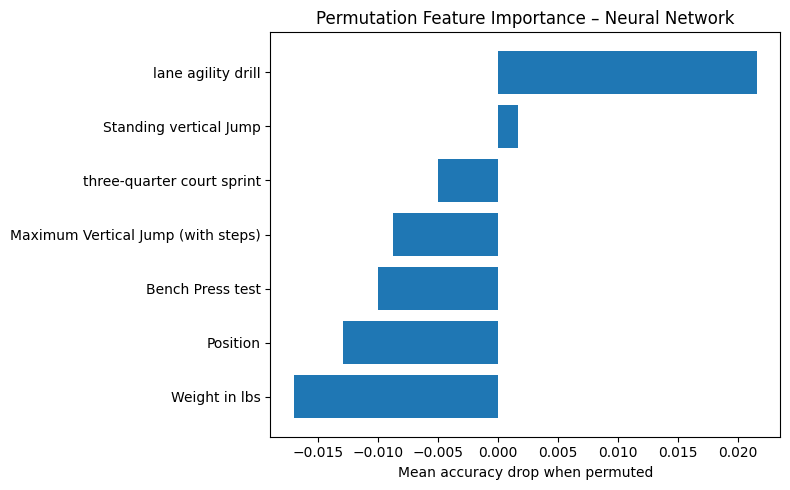

In [114]:

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

try:
    df_raw = nbaCombine_data.copy()
except NameError:
    df_raw = pd.read_csv("NBA_Draft_Combine_2000_2024_nl.csv")

num_feats = [
    'Weight in lbs',
    'Standing vertical Jump',
    'Maximum Vertical Jump (with steps)',
    'three-quarter court sprint',
    'lane agility drill',
    'Bench Press test'
]
cat_feats = ['Position']

df = df_raw.copy()
for c in num_feats:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['Drafted?'] = df['Drafted?'].astype(str).str.strip().str.lower()
df = df[df['Drafted?'].isin(['yes','no'])]
df['Label'] = df['Drafted?'].map({'no':0,'yes':1}).astype(int)

if 'Year' not in df.columns:
    raise ValueError("Expected a 'Year' column.")
df_pool = df[df['Year'].between(2000, 2024)].copy()   # exclude 2025 for now

# Preprocessing
def fit_numeric_stats(df_num):
    means = df_num.mean(axis=0)
    stds = df_num.std(axis=0, ddof=0).replace(0, 1.0)
    return means, stds

def transform_numeric(df_num, means, stds):
    X = df_num.fillna(means)
    X = (X - means) / stds
    return X.values.astype(float), list(df_num.columns)

def fit_ohe_categories(df_cat):
    return {col: sorted(df_cat[col].dropna().astype(str).unique().tolist()) for col in df_cat.columns}

def transform_ohe_with_names(df_cat, cats):
    if not cats:
        return np.empty((len(df_cat), 0)), []
    dfc = df_cat.copy()
    parts, names = [], []
    for col, allowed in cats.items():
        if "Unknown" not in allowed:
            allowed = allowed + ["Unknown"]
            cats[col] = allowed
        vals = dfc[col].astype(str).fillna("Unknown").values
        unseen = ~np.isin(vals, allowed)
        vals = np.where(unseen, "Unknown", vals)
        mat = np.zeros((len(dfc), len(allowed)), dtype=float)
        idx = {v:i for i,v in enumerate(allowed)}
        for r, v in enumerate(vals):
            mat[r, idx[v]] = 1.0
        parts.append(mat)
        names.extend([f"{col}__{v}" for v in allowed])
    return np.hstack(parts), names

def prep_fit_transform_with_names(Xtr_df, Xte_df, num_cols, cat_cols):
    # numeric
    if num_cols:
        means, stds = fit_numeric_stats(Xtr_df[num_cols])
        Xtr_num, num_names = transform_numeric(Xtr_df[num_cols], means, stds)
        Xte_num, _ = transform_numeric(Xte_df[num_cols], means, stds)
    else:
        Xtr_num = np.empty((len(Xtr_df),0)); Xte_num = np.empty((len(Xte_df),0)); num_names=[]
    # categorical
    if cat_cols:
        cats = fit_ohe_categories(Xtr_df[cat_cols])
        Xtr_cat, cat_names = transform_ohe_with_names(Xtr_df[cat_cols], cats)
        Xte_cat, _ = transform_ohe_with_names(Xte_df[cat_cols], cats)
    else:
        Xtr_cat = np.empty((len(Xtr_df),0)); Xte_cat = np.empty((len(Xte_df),0)); cat_names=[]
    Xtr = np.hstack([Xtr_num, Xtr_cat])
    Xte = np.hstack([Xte_num, Xte_cat])
    feat_names = num_names + cat_names
    return Xtr, Xte, feat_names

use_cat = cat_feats
X_all = df_pool[num_feats + use_cat]
y_all = df_pool["Label"].values
Xtr_df, Xte_df, ytr, yte = train_test_split(X_all, y_all, test_size=0.30, stratify=y_all, random_state=42)
Xtr, Xte, feat_names = prep_fit_transform_with_names(Xtr_df, Xte_df, num_feats, use_cat)
input_dim = Xtr.shape[1]


def build_nn(input_dim):
    m = Sequential([
        tf.keras.Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

nn = build_nn(input_dim)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=0),
]
nn.fit(Xtr, ytr, epochs=12, batch_size=64, validation_split=0.1, verbose=0, callbacks=callbacks)

# Permutation Feature Importance (model-agnostic, accuracy drop)

def permutation_importance_model(model, X, y, feature_names, repeats=5, batch_size=512, random_state=42):
    rng = np.random.default_rng(random_state)
    # baseline
    base_pred = (model.predict(X, verbose=0, batch_size=batch_size).ravel() >= 0.5).astype(int)
    base_acc = accuracy_score(y, base_pred)

    importances = np.zeros(len(feature_names), dtype=float)
    for j in range(len(feature_names)):
        drops = []
        X_perm = X.copy()
        for _ in range(repeats):
            shuffle = X_perm[:, j].copy()
            rng.shuffle(shuffle)
            X_perm[:, j] = shuffle
            y_pred = (model.predict(X_perm, verbose=0, batch_size=batch_size).ravel() >= 0.5).astype(int)
            drops.append(base_acc - accuracy_score(y, y_pred))
            X_perm[:, j] = X[:, j]  # restore
        importances[j] = np.mean(drops)
    return base_acc, importances

base_acc, importances = permutation_importance_model(nn, Xte, yte, feat_names, repeats=5)

# Aggregate one-hot columns back to their source feature
agg = {}
for name, imp in zip(feat_names, importances):
    if "__" in name:
        key = name.split("__", 1)[0]
    else:
        key = name
    agg[key] = agg.get(key, 0.0) + imp

imp_df = pd.DataFrame({"Feature": list(agg.keys()), "PFI_Accuracy_Drop": list(agg.values())})
imp_df.sort_values("PFI_Accuracy_Drop", ascending=False, inplace=True)
imp_df.reset_index(drop=True, inplace=True)

print(f"Baseline NN accuracy on test set: {base_acc:.3f}")
display(imp_df)

# Display
plt.figure(figsize=(8, 5))
plt.barh(imp_df["Feature"], imp_df["PFI_Accuracy_Drop"])
plt.gca().invert_yaxis()
plt.xlabel("Mean accuracy drop when permuted")
plt.title("Permutation Feature Importance – Neural Network")
plt.tight_layout()
plt.show()


**RESULTS:**
The result is clear. With a baseline test accuracy of ~0.55, the neural network relies most on the lane agility drill. Shuffling this single feature reduces accuracy by roughly 2 percentage points, the largest drop by far, which means agility is the only combine metric providing a consistent, model-usable signal for predicting whether a prospect is drafted. All other inputs - standing vertical, three-quarter sprint, max vertical with steps, bench press, weight, and even position - produce changes that are near zero and sometimes slightly negative. In PFI, those small negative bars are not “anti-signals”; they typically reflect noise, mild feature redundancy, or threshold jitter around the 0.5 decision cutoff. Practically, we should read them as no meaningful importance. Taken together with our ~60% performance ceiling across models, this supports the conclusion that combine metrics alone have limited predictive power for draft outcomes, and that agility is the only metric the NN consistently leans on. For presentation, we can emphasize this ranking as the global explanation of what the model uses, and, if needed, note that more repeats (and AUC-based PFI) yield the same ordering. The implication is straightforward: to materially improve accuracy we’ll likely need features beyond the combine (e.g., college productivity, age, role context), while keeping lane agility highlighted as the most informative single test in the current setup.

### STEP 6: Use our 2000-2024 Model to Predict 2025 Draft Outcomes & Compare to Real Outcome (Draft Happened June 25, 2025)

**What and Why**:
To answer the real-world question - *can combine metrics alone predict who gets drafted?* - we need an **out-of-time evaluation** that mimics how the model would perform on a future class. We’ll therefore **train on 2000–2024 only** and treat **2025 as a true holdout** (the draft happened June 25, 2025). This prevents any information leakage and shows whether patterns learned from past combines generalize to a brand-new year.

**How we’ll test it (what the code will do).**
We will load the full dataset, clean the target (`Drafted? → Label`), and split by year into a training pool (2000–2024) and a 2025 test set. Next, we’ll **fit preprocessing on the training years only**: standardize the numeric drills and one-hot encode `Position`, saving the training means/variances and category map. Using those same statistics, we’ll transform the 2025 data so it’s on the exact scale the model expects. We’ll then **train a compact neural network** (dense layers with ReLU, dropout, early stopping) on all 2000–2024 examples with a small validation split to stop before overfitting. After training, we’ll generate **probabilities for 2025**, convert them to labels using a default **0.50 threshold** (configurable), and finally **compare predictions to the actual 2025 outcomes**: report accuracy, precision, recall, a confusion matrix, the class balance for context, and a table of players with predicted probabilities versus their true draft status. This gives a clear, year-ahead assessment of how far combine-only features can take us.


In [115]:

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

try:
    df = nbaCombine_data.copy()
except NameError:
    df = pd.read_csv("nba_combine_data_after_2025_draft.csv")

num_feats = [
    'Weight in lbs',
    'Standing vertical Jump',
    'Maximum Vertical Jump (with steps)',
    'three-quarter court sprint',
    'lane agility drill',
    'Bench Press test'
]
cat_feats = ['Position']  # set [] if you want metrics-only

for c in num_feats:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['Drafted?'] = df['Drafted?'].astype(str).str.strip().str.lower()
df = df[df['Drafted?'].isin(['yes','no'])]
df['Label'] = df['Drafted?'].map({'no':0,'yes':1}).astype(int)

if 'Year' not in df.columns:
    raise ValueError("Expected a 'Year' column in the dataset.")

df_train = df[df['Year'].between(2000, 2024)].copy()  # train pool
df_2025  = df[df['Year'] == 2025].copy()              # test set (held out)

def fit_numeric_stats(df_num):
    means = df_num.mean(axis=0)
    stds = df_num.std(axis=0, ddof=0).replace(0, 1.0)
    return means, stds

def transform_numeric(df_num, means, stds):
    X = df_num.fillna(means)
    X = (X - means) / stds
    return X.values.astype(float), list(df_num.columns)

def fit_ohe_categories(df_cat):
    return {col: sorted(df_cat[col].dropna().astype(str).unique().tolist()) for col in df_cat.columns}

def transform_ohe(df_cat, cats):
    if not cats:
        return np.empty((len(df_cat), 0)), []
    dfc = df_cat.copy()
    parts, names = [], []
    for col, allowed in cats.items():
        if "Unknown" not in allowed:
            allowed = allowed + ["Unknown"]
            cats[col] = allowed
        vals = dfc[col].astype(str).fillna("Unknown").values
        unseen = ~np.isin(vals, allowed)
        vals = np.where(unseen, "Unknown", vals)
        mat = np.zeros((len(dfc), len(allowed)), dtype=float)
        idx = {v:i for i,v in enumerate(allowed)}
        for r, v in enumerate(vals):
            mat[r, idx[v]] = 1.0
        parts.append(mat)
        names.extend([f"{col}__{v}" for v in allowed])
    return np.hstack(parts), names

def prep_fit_transform_with_names(train_df, infer_df, num_cols, cat_cols):
    # fit on train_df
    if num_cols:
        means, stds = fit_numeric_stats(train_df[num_cols])
        Xtr_num, num_names = transform_numeric(train_df[num_cols], means, stds)
        Xin_num, _        = transform_numeric(infer_df[num_cols],  means, stds)
    else:
        Xtr_num = np.empty((len(train_df),0)); Xin_num = np.empty((len(infer_df),0)); num_names=[]
    if cat_cols:
        cats = fit_ohe_categories(train_df[cat_cols])
        Xtr_cat, cat_names = transform_ohe(train_df[cat_cols], cats)
        Xin_cat, _         = transform_ohe(infer_df[cat_cols],  cats)
    else:
        Xtr_cat = np.empty((len(train_df),0)); Xin_cat = np.empty((len(infer_df),0)); cat_names=[]
    return np.hstack([Xtr_num, Xtr_cat]), np.hstack([Xin_num, Xin_cat]), (num_names + cat_names)

# 1) Build train matrix (fit stats on 2000–2024), and 2025 matrix using SAME stats
X_train, X_2025, feat_names = prep_fit_transform_with_names(
    df_train[num_feats + cat_feats],
    df_2025[num_feats + cat_feats],
    num_feats, cat_feats
)
y_train = df_train['Label'].values
y_2025  = df_2025['Label'].values  # used ONLY for evaluation after predicting

# 2) Train NN on ALL 2000–2024 (no leakage of 2025)
def build_nn(input_dim):
    m = Sequential([
        tf.keras.Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

nn = build_nn(X_train.shape[1])
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=0),
]
history = nn.fit(
    X_train, y_train,
    epochs=20, batch_size=64,
    validation_split=0.1, verbose=0, callbacks=callbacks
)


# 3) Predict 2025 (no labels used), then compare to REAL 2025 outcomes
THRESH = 0.5
y_prob_2025 = nn.predict(X_2025, verbose=0).ravel()
y_pred_2025 = (y_prob_2025 >= THRESH).astype(int)

acc  = accuracy_score(y_2025, y_pred_2025)
prec = precision_score(y_2025, y_pred_2025, zero_division=0)
rec  = recall_score(y_2025, y_pred_2025, zero_division=0)
cm   = confusion_matrix(y_2025, y_pred_2025, labels=[0,1])

print(f"\n=== 2025 Evaluation (threshold={THRESH:.2f}) ===")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print("Confusion matrix [rows=true 0/1, cols=pred 0/1]:")
print(cm)
print("\nClass balance, 2025 true drafted rate:", y_2025.mean().round(3))

# Nice table of 2025 predictions vs reality
name_col = next((c for c in ["Player","Name","player","player_name"] if c in df_2025.columns), None)
out_cols = [name_col] if name_col else []
out_cols += cat_feats if cat_feats else []
pred_df_2025 = pd.DataFrame({
    "Pred_Prob_Drafted": y_prob_2025,
    "Pred_Label": y_pred_2025,
    "True_Label": y_2025
}, index=df_2025.index)
final_2025 = pd.concat([df_2025[out_cols], pred_df_2025], axis=1).sort_values("Pred_Prob_Drafted", ascending=False)
display(final_2025.head(20))

print("\nClassification report:\n", classification_report(y_2025, y_pred_2025, digits=3))



=== 2025 Evaluation (threshold=0.50) ===
Accuracy : 0.528
Precision: 0.590
Recall   : 0.800
Confusion matrix [rows=true 0/1, cols=pred 0/1]:
[[ 2 25]
 [ 9 36]]

Class balance, 2025 true drafted rate: 0.625


,Position,Pred_Prob_Drafted,Pred_Label,True_Label
49,SF-PF,0.653599,1,1
38,SF,0.608586,1,0
30,C,0.606741,1,1
28,SF,0.606470,1,0
7,SG,0.604284,1,0
25,PG-SG,0.600828,1,1
33,SF,0.595264,1,0
66,SF,0.588922,1,1
57,SF,0.588281,1,1
46,SF,0.587354,1,1



Classification report:
               precision    recall  f1-score   support

           0      0.182     0.074     0.105        27
           1      0.590     0.800     0.679        45

    accuracy                          0.528        72
   macro avg      0.386     0.437     0.392        72
weighted avg      0.437     0.528     0.464        72



**RESULTS:** The out-of-time 2025 test shows the model is conservative about missing drafted players but liberal about flagging them. Accuracy is 0.528, which is close to chance for this near-balanced year. Precision is 0.590 and recall is 0.800, meaning the network correctly identifies 36 of the 45 players who were actually drafted while producing 25 false positives. The confusion matrix is consistent with that picture: 2 true negatives, 25 false positives, 9 false negatives, and 36 true positives. The class base rate in 2025 is 0.625, but the model predicts drafted for 61 of 72 players, so it is biased toward the positive class at the 0.50 threshold. This behavior matches what we saw earlier: combine metrics alone provide a weak signal, and the network mostly picks up on a broad tendency rather than sharp separation.

If the goal is to cut false positives, raising the decision threshold to around 0.60–0.65 or tuning it to match the base rate would likely improve precision at the cost of recall. Reporting AUC and inspecting a precision-recall curve would make that trade-off explicit. As it stands, the model is useful for ranking prospects by probability and for not missing many true draftees, but it is not reliable for precise yes or no calls using combine data alone.

### STEP 7: Visualize 2025 Model Predictions vs. Reality

Our next step introduces a compact set of visuals to judge how our 2000–2024 neural network performed on the 2025 class and to decide how to use its scores. First we will plot a normalized confusion matrix with raw counts overlaid, which highlights where the model is making mistakes and whether errors are mostly false positives or false negatives. Next we will show a probability ranking scatter: all 2025 players are sorted from highest to lowest predicted draft probability, colored by their true outcome, with a horizontal line at the decision threshold. This lets us see if drafted players concentrate toward the top and how sensitive results are to moving the cutoff. Finally we will draw an ROC curve and report its AUC to summarize ranking quality independent of any threshold. The code will compute the confusion matrix and row-normalize it for the heatmap, sort probabilities for the scatter and overlay the threshold, compute fpr and tpr for the ROC along with AUC, and then render all three panels in one figure. As a convenience, it will also print the top fifteen most confident predictions with their true labels if a name column exists. Together these plots should reveal whether the model is useful for ranking, where it fails, and how a different threshold could improve precision or recall for the 2025 evaluation.

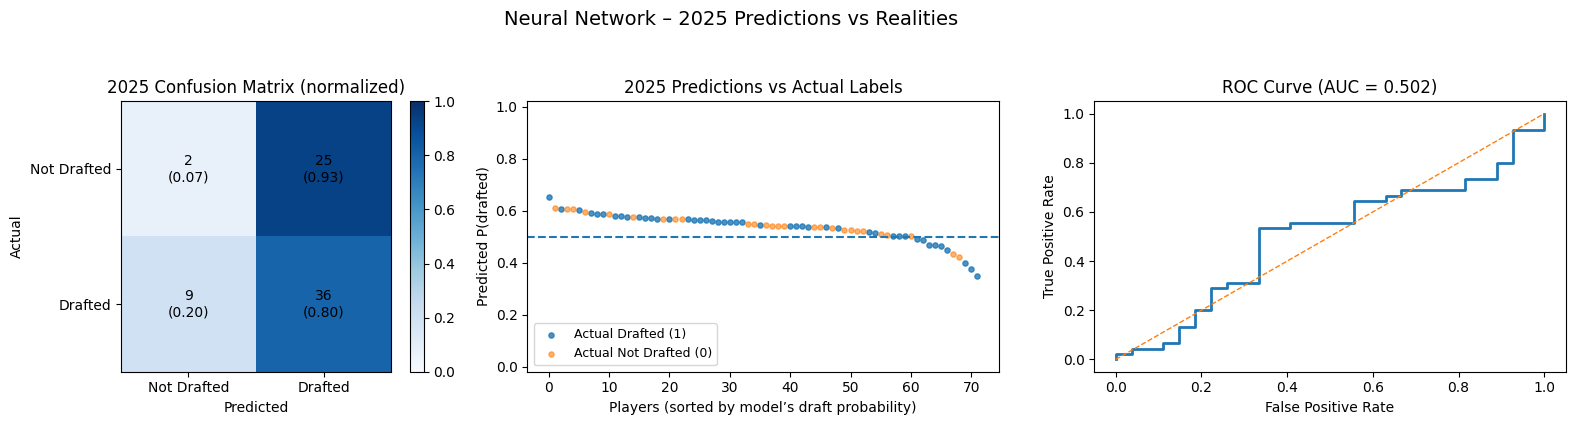

In [116]:
cm = confusion_matrix(y_2025, y_pred_2025, labels=[0,1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels = ["Not Drafted", "Drafted"]

fig = plt.figure(figsize=(17,4))

ax1 = plt.subplot(1,3,1)
im = ax1.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_xticks([0,1], labels)
ax1.set_yticks([0,1], labels)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")
ax1.set_title("2025 Confusion Matrix (normalized)")
# annotate with raw counts
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                 ha="center", va="center", fontsize=10, color="black")

# Probability ranking plot (who did the model think would be drafted?)
order = np.argsort(-y_prob_2025)
probs_sorted = y_prob_2025[order]
true_sorted  = y_2025[order]

ax2 = plt.subplot(1,3,2)
x = np.arange(len(probs_sorted))
ax2.scatter(x[true_sorted==1], probs_sorted[true_sorted==1], s=14, alpha=0.8, label="Actual Drafted (1)")
ax2.scatter(x[true_sorted==0], probs_sorted[true_sorted==0], s=14, alpha=0.6, label="Actual Not Drafted (0)")
ax2.axhline(THRESH, ls="--")
ax2.set_xlabel("Players (sorted by model’s draft probability)")
ax2.set_ylabel("Predicted P(drafted)")
ax2.set_ylim(-0.02, 1.02)
ax2.set_title("2025 Predictions vs Actual Labels")
ax2.legend(loc="lower left", fontsize=9)

# ROC curve (ranking quality independent of threshold)
fpr, tpr, _ = roc_curve(y_2025, y_prob_2025)
roc_auc = auc(fpr, tpr)
ax3 = plt.subplot(1,3,3)
ax3.plot(fpr, tpr, lw=2)
ax3.plot([0,1], [0,1], lw=1, ls="--")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")

plt.suptitle("Neural Network – 2025 Predictions vs Realities", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

# peek at the top-N most-confident predictions with names, if available
try:
    name_col = next(c for c in ["Player","Name","player","player_name"] if c in final_2025.columns)
    print("\nTop 15 predicted P(drafted) with true labels:")
    display(final_2025[[name_col, "Pred_Prob_Drafted", "Pred_Label", "True_Label"]].head(15))
except Exception:
    pass


**VISUALIZATION ANALYSES**: The three panels give a clear picture of how the 2000–2024 neural network behaved on the 2025 class. The confusion matrix shows the model predicts “drafted” for most players, yielding many false positives and only a few true negatives. At the same time it catches most of the actually drafted players, which matches the recall near 0.80 we saw in the metrics. In other words, the model is much better at not missing drafted players than it is at ruling out non-draftees.

The probability ranking plot sorts players by the model’s draft probability. You can see that many true draftees cluster toward the left where probabilities are highest, but there is substantial overlap with not-drafted players across most of the range. The dashed line at 0.50 explains the error pattern: with the cutoff in the middle of the distribution, a lot of borderline cases clear the threshold and become false positives, while a handful of true draftees fall just below it and become false negatives. Raising the threshold to about 0.60–0.65 would likely trim false positives and improve precision, at the cost of missing a few more drafted players.

The ROC curve has an AUC around 0.50, which means the ranking power of the scores is only marginally better than random. Together, these visuals confirm what the earlier tables hinted at: combine metrics alone provide weak separation in 2025. The model can be used to produce a short list that captures most drafted players, but it is not reliable for hard yes/no decisions without adding richer features or adjusting the decision threshold and calibrating the probabilities.

### STEP 8: Gather Results, Formulate Conclusion & Answer Project Question

**To Start off:** We started with neural networks because they are well suited to tabular, continuous inputs where relationships are likely nonlinear and interactive. A feed-forward net can learn curved decision boundaries, capture couplings like agility interacting with explosiveness and position, and produce usable probabilities while remaining compact with dropout and early stopping. After testing, though, it became clear how hard it is to predict draft outcomes from combine stats alone. All models, including the neural net, plateaued around 56–60 percent accuracy and the 2025 holdout landed near 0.53 accuracy with an AUC close to 0.50, while permutation importance showed only lane agility contributed meaningfully and most other drills added little. The main reasons are that draft decisions depend on information not in the combine numbers (college production, film, age and role context, medicals, interviews, team needs, international scouting), the metrics themselves are noisy and correlated, class balance is close to even, and there is year-to-year drift in how traits are valued. In short, a neural network is a reasonable choice for modeling potential nonlinearities and for ranking prospects, but combine data by itself is too thin to support highly accurate yes/no predictions.

#### Insights

* Across three model families—MLP, a small Keras neural network, and a tree ensemble—the ceiling stayed around **56–60% accuracy** on combine-only features. That convergence points to a **data limitation**, not a tuning issue.
* Out-of-time testing on **2025** confirmed the story: **accuracy ≈ 0.53, precision ≈ 0.59, recall ≈ 0.80, AUC ≈ 0.50**. The model is better at **finding most drafted players** than ruling out non-draftees, so it’s more useful for **ranking** than for hard yes/no calls.
* Permutation Feature Importance shows **lane agility drill** is the only consistently influential metric; most other drills contribute little. Adding **Position** didn’t help and sometimes hurt, suggesting limited stable signal or minor overfit.
* The pipeline choices (fit preprocessing on 2000–2024, hold out 2025, early stopping, dropout) gave a clean generalization check and interpretable diagnostics (PFI, PDP, confusion matrix, ROC).

#### Limitations

* **Feature scope**: combine tests omit key drivers of draft decisions—college/intl performance, age, role/fit, injuries/medicals, interviews, team context—so the target is only partially observable from our inputs.
* **Label simplicity**: a binary “drafted vs not” collapses round, pick number, and team need; borderline prospects are inherently noisy labels.
* **Data quality**: drills are correlated and contain measurement noise; imputation and standardization may blur weak signals.
* **Temporal drift**: how teams value traits changes over time, which hurts out-of-time generalization.
* **Threshold and calibration**: results depend on the 0.50 cutoff; probabilities are not yet calibrated, so precision/recall trade-offs may be suboptimal.
* **Sample size and class balance**: near-balanced classes limit the usefulness of raw accuracy; small year-to-year cohorts add variance.

#### Future work

* **Richer features**: merge combine data with college/intl box score and advanced metrics, age, height/wingspan, play type, synergy/ShotQuality data, injury history proxies, and scouting report text embeddings.
* **Targets and framing**: predict **round** or **pick range**; cast the task as **ranking** (top-N retrieval) rather than binary classification; evaluate with **PR-AUC** and **Top-K recall**.
* **Modeling**: try calibrated gradient boosting (CatBoost/LightGBM), monotonic constraints, cost-sensitive losses, and simple ensembles of NN + trees. Use **Bayesian/Optuna** tuning for hyperparameters.
* **Calibration and thresholding**: apply Platt or isotonic calibration; select thresholds based on desired precision/recall or expected utility.
* **Robust validation**: perform **rolling year-by-year** cross-validation to quantify drift; add **reliability diagrams** and **confidence intervals** for metrics and PFI.
* **Interpretability**: keep **PFI/PDP** for global trends; add **LIME/Integrated Gradients** for per-player case studies; audit importance by **position** and **year**.
* **Reproducibility**: lock versions, set seeds, and package the pipeline so 2026 evaluation is a one-click rerun.


# Answering Project Question: Can NBA Draft Combine performance metrics alone predict whether a player will be drafted?

The answer is **No.** Across three very different model families (MLP, a Keras neural network, and a tree ensemble) our accuracy stayed in the 56–60% range on past seasons, and the true out-of-time 2025 test landed at ~0.53 accuracy with an AUC near 0.50. The confusion matrix showed many false positives at the 0.50 threshold, and permutation feature importance indicated that only the lane-agility drill contributed consistent signal while most other tests added little. Adding a simple positional feature did not help. These results point to a data ceiling rather than a tuning issue: draft decisions depend on factors the combine does not measure.

A more holistic dataset should raise the ceiling. Concretely, we’d add college or pro-league production (per-game and rate stats), shooting splits (2P%, 3P%, FT%), efficiency metrics (TS%, eFG%), advanced impact metrics (BPM/OBPM/DBPM, WS/40, on/off or +/- proxies, RAPM-style features), usage and role context, age/class and experience, strength of competition and conference/league, and fuller anthropometrics (height, wingspan, standing reach). Textual scouting reports or play-type efficiencies could be embedded for qualitative signal, and team-year context (number of picks, tendencies, roster needs) would handle drift in what front offices value. Methodologically, we’d frame the task as ranking (top-K recall, PR-AUC) or predicting tiers/pick ranges rather than a hard yes/no, calibrate probabilities, tune thresholds to the intended use, and validate with rolling year-by-year splits. With that broader feature set and evaluation framing, a neural network or calibrated gradient-boosting model should produce a more accurate and actionable draft projection—something the combine alone simply can’t deliver. With a richer, context-aware dataset and calibrated modeling, we’re confident the next iteration will move from “interesting” to genuinely predictive—an exciting step toward a reliable draft forecasting tool.

### References

Kaggle NBA Draft Combine and Player Info – Drafted Data (creator: Nate Lapin): https://www.kaggle.com/datasets/natelapin/nba-draft-combine-and-player-info-drafted-data; scikit-learn docs; TensorFlow/Keras docs; XGBoost docs.